In [10]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math

In [15]:
embs = {
    "金毛":[0.2,0.4,0.8,-0.1],
    "西瓜":[-3.7,-4.2,1.1,2.1],
    "丁师兄":[-2.4,0.1,-0.3,4.5]
}

q = torch.FloatTensor([list(embs.values())])
k = torch.FloatTensor([list(embs.values())])
v = torch.FloatTensor([list(embs.values())])


print("q",q,q.shape)
print("k",k,k.shape)
print("v",v,v.shape)

q tensor([[[ 0.2000,  0.4000,  0.8000, -0.1000],
         [-3.7000, -4.2000,  1.1000,  2.1000],
         [-2.4000,  0.1000, -0.3000,  4.5000]]]) torch.Size([1, 3, 4])
k tensor([[[ 0.2000,  0.4000,  0.8000, -0.1000],
         [-3.7000, -4.2000,  1.1000,  2.1000],
         [-2.4000,  0.1000, -0.3000,  4.5000]]]) torch.Size([1, 3, 4])
v tensor([[[ 0.2000,  0.4000,  0.8000, -0.1000],
         [-3.7000, -4.2000,  1.1000,  2.1000],
         [-2.4000,  0.1000, -0.3000,  4.5000]]]) torch.Size([1, 3, 4])


手撕多头注意力

In [20]:
#这段代码是构建大语言模型（LLM）或 Transformer 时的 标准起手式。它将模型的超参数（Hyperparameters）封装在一个结构中，
# 方便后续在定义模型网络结构（如 class Transformer(nn.Module)）时统一传递和管理这些配置。
from dataclasses import dataclass
@dataclass
class ModelArgs:
    n_heads:int
    dim : int  #隐藏层维度（个人理解为每个头的层维度*头数）也就是总的维度
    max_seq_len:int #需要做掩码机制，需要定义输入序列的最大长度
    dropout:float



In [30]:


#多头注意力机制的核心代码实现
class MultiHeadAttention(nn.Module):

    def __init__(self,args:ModelArgs,is_causual=False):

        #初始化父类
        super().__init__()

        #判断隐藏层维度是否能被头数（n_heads)整除,assert成立继续运行，不成立抛出异常
        assert args.dim % args.n_heads == 0

        #计算头的维度
        self.head_dim = args.dim//args.n_heads

        #成员变量的赋值
        self.n_heads = args.n_heads
        self.is_casual = is_causual

        #Wq,Wk,Wv的变换矩阵，shape = [dim，dim]，nn.Linear的作用是特征重组器，
        # 不再是原始的 Embedding，而是被投影到了一个新的空间（Query 空间
        self.wq = nn.Linear(args.dim, self.head_dim*self.n_heads,bias=False)
        self.wk = nn.Linear(args.dim, self.head_dim*self.n_heads,bias=False)
        self.wv = nn.Linear(args.dim, self.head_dim*self.n_heads,bias=False)
        #Wo输出变换矩阵,shape = [dim,dim]
        self.wo = nn.Linear( self.head_dim*self.n_heads,args.dim,bias=False)

        #注意力层的dropout
        self.attn_dropout = nn.Dropout(args.dropout)
        #残差部分的dropout
        self.res_dropout = nn.Dropout(args.dropout)

        #掩码下三角矩阵，屏蔽未来的token
        if is_causual:
            #[batch_size,n_heads,seq_len,seq_len) 1,1是因为广播机制
            mask = torch.full((1,1,args.max_seq_len,args.max_seq_len),float('-inf'))
            mask = torch.triu(mask,diagonal=1)
            #注册缓冲区   掩码是固定张量（不参与梯度计算） 但需要随模型一起保存/加载
            self.register_buffer("mask",mask)

    def forward(self,q,k,v):

        #[batch_size,seq_len,dim]
        batch_size,seq_len,dim =q.shape

        #计算Q,K,V，维度为[batch_size,seq_len,dim]*[dim，dim] ->> [batch_size,seq_len,dim]
        Q,K,V = self.wq(q),self.wk(k),self.wv(v)

        #将Q K V拆分成多头，[batch_size,seq_len,n_heads,head_dim]
        Q = Q.view(batch_size,seq_len,self.n_heads,self.head_dim)
        K = K.view(batch_size,seq_len,self.n_heads,self.head_dim)
        V = V.view(batch_size,seq_len,self.n_heads,self.head_dim)
        #交换seq_len和n_heads的位置，方便并行计算  [batch_size,n_heads,seq_len,head_dim]
        Q = Q.transpose(1,2)
        K = K.transpose(1,2)
        V = V.transpose(1,2)

        #注意力机制的计算
        #Q*K转/sqrt(dk)
        # [batch_size,n_heads,seq_len,head_dim]*[batch_size,n_heads,head_dim,seq_len]
        # =[batch_size,n_heads,seq_len,seq_len]
        scores = torch.matmul(Q,K.transpose(2,3))/math.sqrt(self.head_dim)

        #计算掩码
        if self.is_casual:
            scores = scores + self.mask[:,:,:seq_len,:seq_len]

        # 计算softmax， [batch_size, n_heads, seq_len, seq_len]
        scores = F.softmax(scores, dim=-1).type_as(Q)

        #计算注意力加权输出 Scores*V
        # 维度：[batch_size,n_heads,seq_len,seq_len]*[batch_size,n_heads,seq_len,head_dim]
        # =[batch_size,n_heads,seq_len,head_dim]
        output = torch.matmul(scores,V)

        #拼接多头注意力的结果，[batch_size,n_heads,seq_len,head_dim]
        # -> [batch_size,seq_len,n_heads*head_dim]-> [batch_size,seq_len,dim]
        output = output.transpose(1,2).contiguous().view(batch_size,seq_len,dim)

        #输出矩阵变换+残差
        output = self.wo(output)
        output = self.res_dropout(output)

        return output,scores

Case 1

In [23]:
 args = ModelArgs(n_heads=2,dim=4,max_seq_len=10,dropout=0.1)
#实例化多头注意力
mha = MultiHeadAttention(args,is_casual=False)
output,att_score = mha(q,k,v)
print("output: ", output)
print("att_score: ", att_score)

output:  tensor([[[-0.8724,  0.9664,  0.0000,  1.1842],
         [-0.3672,  0.3285, -0.0545,  0.4814],
         [-1.0231,  0.9901,  0.0000,  0.0000]]], grad_fn=<MulBackward0>)
att_score:  tensor([[[[0.4318, 0.2691, 0.2991],
          [0.8663, 0.0327, 0.1010],
          [0.3604, 0.2126, 0.4269]],

         [[0.3369, 0.3421, 0.3210],
          [0.5659, 0.2756, 0.1585],
          [0.6212, 0.2644, 0.1144]]]], grad_fn=<SoftmaxBackward0>)


[[0.33689773 0.34214765 0.32095462]
 [0.5659086  0.2755835  0.15850782]
 [0.6212232  0.2644243  0.11435248]]


<Axes: >

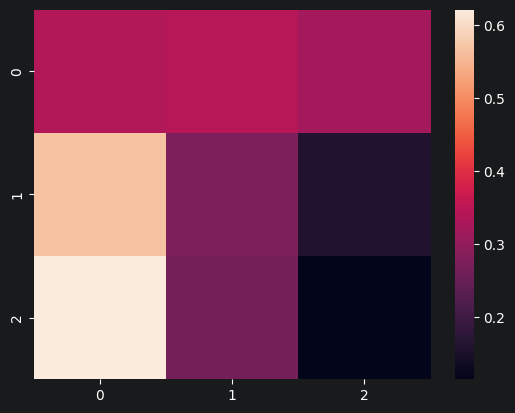

In [28]:
import seaborn as sns
print(att_score[0, 1].detach().numpy())
#.detach是为了将tensor从计算中分离出来，不再计算梯度，Matplotlib/Seaborn 无法直接处理这种带有梯度的 Tensor
#.numpy将 PyTorch Tensor 转换为标准的 NumPy 数组。这是 Python 科学计算和绘图库通用的数据格式
sns.heatmap(att_score[0, 1].detach().numpy())

In [31]:
mha = MultiHeadAttention(args, is_casual=True)
output, att_score = mha(q, k, v)
print("output: ", output)
print("att_score: ", att_score)

output:  tensor([[[-0.8945,  0.1961, -0.0200, -0.6121],
         [-0.0000,  0.0000,  0.3812, -0.0000],
         [-1.6120,  0.0000,  0.3553, -0.0000]]], grad_fn=<MulBackward0>)
att_score:  tensor([[[[4.8626e-01, 2.1892e-01, 2.9482e-01],
          [9.4118e-05, 9.8255e-01, 1.7360e-02],
          [6.0538e-04, 9.6454e-01, 3.4851e-02]],

         [[3.6754e-01, 3.3492e-01, 2.9754e-01],
          [4.8153e-01, 4.2273e-01, 9.5740e-02],
          [3.7046e-01, 3.0187e-01, 3.2768e-01]]]], grad_fn=<SoftmaxBackward0>)


[[0.36753684 0.33492076 0.2975423 ]
 [0.48153183 0.42272812 0.0957401 ]
 [0.37045786 0.30186522 0.32767692]]


<Axes: >

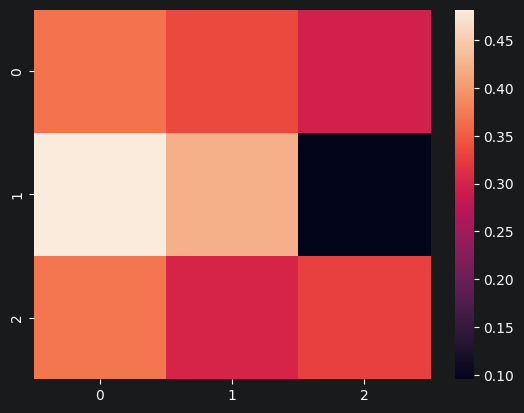

In [32]:
print(att_score[0, 1].detach().numpy())

sns.heatmap(att_score[0, 1].detach().numpy())

In [33]:
args = ModelArgs(n_heads=8, dim=1024, dropout=0.1, max_seq_len=512)
print(args)

batch_size = 10
seq_len = 128

x = torch.randn(batch_size, seq_len, args.dim)

# MHA
mha = MultiHeadAttention(args, is_casual=False)
output, att_score = mha(x, x, x)
print("output shape: ", output.shape)
print("att_score shape: ", att_score.shape)

ModelArgs(n_heads=8, dim=1024, max_seq_len=512, dropout=0.1)
output shape:  torch.Size([10, 128, 1024])
att_score shape:  torch.Size([10, 8, 128, 128])
